In [1]:
<< FeynCalc`;

FeynCalc 10.1.0 (stable version). For help, use the online documentation,
 
>    visit the forum and have a look at the supplied examples.
 
>    The PDF-version of the manual can be downloaded here.
If you use FeynCalc in your research, please evaluate FeynCalcHowToCite[] to\
 
>   learn how to cite this software.
Please keep in mind that the proper academic attribution of our work is\
 
>   crucial to ensure the future development of this package!


In [6]:
mu=\[Mu]
nu=\[Nu]
a=\[Alpha]
b=\[Beta]
n=\[Eta]
l=\[Lambda]

SPD[p,p] = x
SPD[q,q] = y
SPD[p,q] = w

μ
ν
α
β
η
λ
x
y
w

In [58]:
prop1 = FAD[{k, 0}];
prop2 = FAD[{p - k, m}];
prop3 = FAD[{q + k, m}];

## Calculando el factor total de corrección $\mathcal{B}$

FAD[{-k + p, m}] (-FVD[k, μ] + 2 FVD[p, μ]) + FAD[{k + q, m}] (FVD[k, μ] + 2 FVD[q, μ])
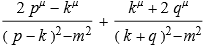

In [65]:
int = (2 FVD[p, mu] - FVD[k, mu]) * prop2 + (2 FVD[q, mu] + FVD[k, mu]) * prop3

I                                                                               2
(- FAD[{k, 0}] (FeynAmpDenominator[PropagatorDenominator[Momentum[-k + p, D], m]]  
 8
 
>        (4 x + Pair[Momentum[k, D], Momentum[k, D]] - 
 
>          4 Pair[Momentum[k, D], Momentum[p, D]]) + 
 
>       2 FeynAmpDenominator[PropagatorDenominator[Momentum[-k + p, D], m]] 
 
>        FeynAmpDenominator[PropagatorDenominator[Momentum[k + q, D], m]] 
 
>        (4 w - Pair[Momentum[k, D], Momentum[k, D]] + 
 
>          2 Pair[Momentum[k, D], Momentum[p, D]] - 
 
>          2 Pair[Momentum[k, D], Momentum[q, D]]) + 
 
                                                                        2
>       FeynAmpDenominator[PropagatorDenominator[Momentum[k + q, D], m]]  
 
>        (4 y + Pair[Momentum[k, D], Momentum[k, D]] + 
 
                                                         3
>          4 Pair[Momentum[k, D], Momentum[q, D]]))) / Pi
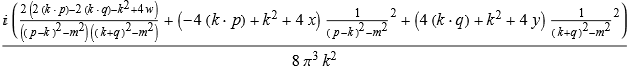

In [70]:
CV = (I)/(8 Pi^3) * prop1 * Contract[int . int]

The result is given in terms of Passarino-Veltman


2   2                     2   2      2                   2   2
B0[0, m , m ]   B0[2 w + x + y, m , m ]   (m  + x) C0[0, x, x, m , m , 0]
------------- - ----------------------- - ------------------------------- - 
    4 Pi                 4 Pi                          4 Pi
 
      2                   2   2
    (m  + y) C0[0, y, y, m , m , 0]
>   ------------------------------- + 
                 4 Pi
 
        2                                       2      2
    (2 m  - 4 w - x - y) C0[x, y, 2 w + x + y, m , 0, m ]
>   -----------------------------------------------------
                            4 Pi
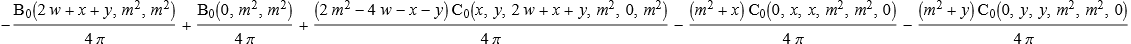

In [75]:
res2 = TID[CV, k];
resPV2 = ToPaVe[res2, k]
Print["The result is given in terms of Passarino-Veltman"]

2   2        2             2   2     2        2   2   2   2
B0[0, m , m ]   B0[m  + 2 w + y, m , m ]   m  C0[0, m , m , m , m , 0]
------------- - ------------------------ - --------------------------- - 
    4 Pi                  4 Pi                        2 Pi
 
      2                   2   2         2                2      2             2      2
    (m  + y) C0[0, y, y, m , m , 0]   (m  - 4 w - y) C0[m , y, m  + 2 w + y, m , 0, m ]
>   ------------------------------- + -------------------------------------------------
                 4 Pi                                       4 Pi
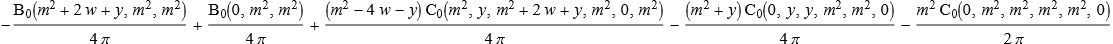

In [82]:
resPV2x = resPV2/.x->m^2

2   2          2         2   2     2        2   2   2   2
B0[0, m , m ]   B0[2 m  + 2 w, m , m ]   m  C0[0, m , m , m , m , 0]
------------- - ---------------------- - --------------------------- - 
    4 Pi                 4 Pi                        Pi
 
          2   2     2         2      2
    w C0[m , m , 2 m  + 2 w, m , 0, m ]
>   -----------------------------------
                    Pi
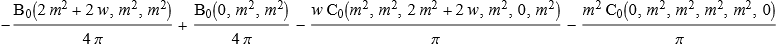

In [87]:
resPV2y = resPV2x/.y->m^2

2   2         2   2   2     2        2   2   2   2
B0[0, m , m ]   B0[mf , m , m ]   m  C0[0, m , m , m , m , 0]
------------- - --------------- - --------------------------- - 
    4 Pi             4 Pi                     Pi
 
         2     2      2   2    2   2      2
    (-2 m  + mf ) C0[m , m , mf , m , 0, m ]
>   ----------------------------------------
                      2 Pi
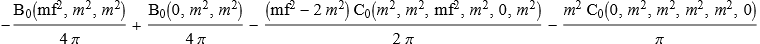

In [92]:
resPV2w = resPV2y/.w->((1/2)*(mf^2 - 2*m^2))